<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

In [95]:
import pandas as pd
import numpy as np
from datetime import datetime
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pearsonr, spearmanr, f_oneway, kruskal, stats
import plotly.graph_objects as go

In [96]:
df_customers = pd.read_csv("customers.csv", sep=';')
df_transactions = pd.read_csv("Transactions.csv", sep=';')
df_products = pd.read_csv("products.csv", sep=';')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

In [97]:
df_transactions.describe(include="all")

,id_prod,date,session_id,client_id
count,687534,687534,687534,687534
unique,3265,687419,345505,8600
top,1_369,2021-10-13 17:05:59.572162,s_118668,c_1609
freq,2340,2,14,25586


In [98]:
# Nombre de lignes où TOUTES les valeurs sont manquantes
lignes_completement_vides = df_transactions.isnull().all(axis=1).sum()
print(f"Nombre de lignes vides : {lignes_completement_vides}")

Nombre de lignes vides : 361041


In [99]:
#Suppression des lignes NaN
df_transactions.drop(df_transactions[(df_transactions["id_prod"].isna()) & (df_transactions["date"].isna()) & (df_transactions["session_id"].isna()) & (df_transactions["client_id"].isna())].index, inplace = True)
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 21.0+ MB


In [100]:
# Nombre de lignes où TOUTES les valeurs sont manquantes
lignes_completement_vides = df_transactions.isnull().all(axis=1).sum()
print(lignes_completement_vides)

0


In [101]:
df_products.describe(include="all")

,id_prod,price,categ
count,3286,3286.000000,3286.000000
unique,3286,NaN,NaN
top,0_1920,NaN,NaN
freq,1,NaN,NaN
mean,NaN,21.863597,0.370359
std,NaN,29.849786,0.615446
min,NaN,0.620000,0.000000
25%,NaN,6.990000,0.000000
50%,NaN,13.075000,0.000000
75%,NaN,22.990000,1.000000


In [102]:
# Nombre de lignes où TOUTES les valeurs sont manquantes
lignes_completement_vides = df_products.isnull().sum()
print(lignes_completement_vides)


id_prod    0
price      0
categ      0
dtype: int64


In [103]:
df_customers.describe(include="all")

,client_id,sex,birth
count,8621,8621,8621.000000
unique,8621,2,NaN
top,c_84,f,NaN
freq,1,4490,NaN
mean,NaN,NaN,1978.275606
std,NaN,NaN,16.917958
min,NaN,NaN,1929.000000
25%,NaN,NaN,1966.000000
50%,NaN,NaN,1979.000000
75%,NaN,NaN,1992.000000


In [104]:
# Nombre de lignes où TOUTES les valeurs sont manquantes
lignes_completement_vides = df_customers.isnull().sum()
print(lignes_completement_vides)

client_id    0
sex          0
birth        0
dtype: int64


In [105]:
#Identification des doublons : colonne "client_id"
df_customers['client_id'].is_unique
#True => pas de doublons

True

In [106]:
#Liste des valeurs uniques : colonne "sex"
pd.unique(df_customers['sex'])

array(['f', 'm'], dtype=object)

In [107]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 21.0+ MB


In [108]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [109]:
# Conversion des dates
df_transactions['date'] = pd.to_datetime(df_transactions['date'])
# Type naissance en int
df_customers['birth'] = pd.to_numeric(df_customers['birth'], errors='coerce')

In [110]:
#Identification des doublons : colonne "id_prod"
df_products['id_prod'].is_unique
#True => aucun doublon

True

In [142]:
df_products[df_products["price"] < 0]


,id_prod,price,categ


In [111]:
#Liste des valeurs uniques : colonne "categ"
pd.unique(df_products['categ'])

array([0, 1, 2])

In [112]:
#Remplacement des chiffres par une nouvelle désignation de catégorie
df_products.loc[df_products['categ']== 0, 'categ']='Categorie_0'
df_products.loc[df_products['categ']== 1, 'categ']='Categorie_1'
df_products.loc[df_products['categ']== 2, 'categ']='Categorie_2'

In [113]:
# Calcul du 1er quartile
Q1 = np.percentile(df_products["price"], 25)
print("Q1 :",Q1)
# Calcul du 3e quartile
Q3 = np.percentile(df_products["price"], 75)
print("Q3 :",Q3)
# Calcul de l'écart interquartile
IQ = Q3 - Q1
print("IQ :",IQ)

#Calcul de la borne inférieure du boxplot
borne_inf_boxplot_price = round(Q1-1.5*IQ,2)
print("Valeur de la borne inférieure du boxplot :",borne_inf_boxplot_price,"€")

#Calcul de la borne supérieure du boxplot
borne_sup_boxplot_price = round(Q3+1.5*IQ,2)
print("Valeur de la borne supérieure du boxplot :",borne_sup_boxplot_price,"€")


Q1 : 6.99
Q3 : 22.99
IQ : 15.999999999999998
Valeur de la borne inférieure du boxplot : -17.01 €
Valeur de la borne supérieure du boxplot : 46.99 €


In [114]:
#Affichage des outliers > 46.99€

outliers_borne_sup = df_products.loc[(df_products['price'] > borne_sup_boxplot_price)].sort_values(by='price', ascending=False).head(20)
print("Nombre d'outliers > 46.99€ :",outliers_borne_sup['price'].count(),"valeurs.")
outliers_borne_sup

Nombre d'outliers > 46.99€ : 20 valeurs.


,id_prod,price,categ
946,2_2,300.00,Categorie_2
724,2_76,254.44,Categorie_2
394,2_158,247.22,Categorie_2
1435,2_167,236.99,Categorie_2
2778,2_30,233.54,Categorie_2
1959,2_125,231.99,Categorie_2
2486,2_166,230.04,Categorie_2
785,2_40,228.11,Categorie_2
10,2_228,225.17,Categorie_2
1895,2_4,222.97,Categorie_2


300 outliers sur 3286 prix au total => 9.13% d'outliers.

Nous n'avons pas plus d'informations sur les produits mais nous constatons que les 20 produits les plus chers sont tous dans la Catégorie n°2.

Nous décidons de conserver l'intégralité des produits de la liste. 

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Jonction des fichiers</h2>
</div>

In [115]:
# =============================================================================
# ANALYSE DE LA JOINTURE ENTRE df_transactions ET df_products
# =============================================================================

print("🔍 DIAGNOSTIC DE LA JOINTURE ENTRE TRANSACTIONS ET PRODUITS")
print("=" * 60)

# 1. JOINTURE OUTER AVEC INDICATEUR POUR DIAGNOSTIC
print("\n📊 Étape 1 : Diagnostic avec jointure OUTER")
df_transactions_products_test = pd.merge(
    df_transactions, 
    df_products, 
    how="outer", 
    on="id_prod", 
    indicator=True
)

# Analyse des correspondances
merge_counts = df_transactions_products_test['_merge'].value_counts()
total_rows = len(df_transactions_products_test)

print(f"Total de lignes après jointure outer : {total_rows:,}")
print("\nRépartition des correspondances :")
for merge_type, count in merge_counts.items():
    percentage = (count / total_rows) * 100
    print(f"  - {merge_type:12} : {count:,} lignes ({percentage:.3f}%)")

# 2. ANALYSE DES LIGNES NON-MATCHÉES
print("\n⚠️  Étape 2 : Analyse des lignes non-matchées")
non_matched = df_transactions_products_test[df_transactions_products_test["_merge"] != "both"]

if len(non_matched) > 0:
    print(f"Nombre de lignes non-matchées : {len(non_matched):,}")
    print("\nDétail des non-correspondances :")
    
    # Transactions orphelines (produits vendus mais absents du catalogue)
    transactions_orphelines = non_matched[non_matched["_merge"] == "left_only"]
    print(f"  - Transactions orphelines : {len(transactions_orphelines):,}")
    
    # Produits jamais vendus
    produits_non_vendus = non_matched[non_matched["_merge"] == "right_only"]
    print(f"  - Produits jamais vendus : {len(produits_non_vendus):,}")
    
    # Affichage des premières lignes non-matchées
    print(f"\nPremières lignes non-matchées :")
    display(non_matched.head(10))
    
    # Analyse des produits jamais vendus par catégorie
    if len(produits_non_vendus) > 0:
        print(f"\n📈 Analyse des {len(produits_non_vendus)} produits jamais vendus :")
        produits_analysis = produits_non_vendus.groupby("categ").agg({
            "id_prod": "count",
            "price": ["min", "max", "mean"]
        }).round(2)
        produits_analysis.columns = ['Nombre', 'Prix_min', 'Prix_max', 'Prix_moyen']
        display(produits_analysis)
else:
    print("✅ Aucune ligne non-matchée trouvée !")

# 3. JOINTURE INNER FINALE
print("\n✅ Étape 3 : Jointure INNER finale (données exploitables)")
df_transactions_products = pd.merge(
    df_transactions, 
    df_products, 
    how="inner", 
    on="id_prod"
)

# Statistiques finales
transactions_initiales = len(df_transactions)
produits_initiaux = len(df_products)
transactions_finales = len(df_transactions_products)
perte_transactions = transactions_initiales - transactions_finales

print(f"Transactions initiales    : {transactions_initiales:,}")
print(f"Produits initiaux         : {produits_initiaux:,}")
print(f"Transactions finales      : {transactions_finales:,}")
print(f"Transactions perdues      : {perte_transactions:,}")
print(f"Taux de conservation      : {(transactions_finales/transactions_initiales)*100:.3f}%")

# 4. APERÇU DU DATASET FINAL
print(f"\n📋 Aperçu du dataset final df_transactions_products :")
print(f"Forme : {df_transactions_products.shape}")
print(f"Colonnes : {list(df_transactions_products.columns)}")

display(df_transactions_products.head())

# 5. RÉSUMÉ EXÉCUTIF
print("\n" + "="*60)
print("📝 RÉSUMÉ EXÉCUTIF")
print("="*60)
print(f"✅ Jointure réussie avec {(transactions_finales/transactions_initiales)*100:.3f}% des transactions conservées")
print(f"✅ Dataset final prêt pour l'analyse avec {transactions_finales:,} transactions")
if perte_transactions > 0:
    print(f"⚠️  {perte_transactions:,} transactions perdues (produits inexistants dans le catalogue)")
if len(produits_non_vendus) > 0:
    print(f"ℹ️  {len(produits_non_vendus):,} produits du catalogue jamais vendus")


🔍 DIAGNOSTIC DE LA JOINTURE ENTRE TRANSACTIONS ET PRODUITS

📊 Étape 1 : Diagnostic avec jointure OUTER
Total de lignes après jointure outer : 687,555

Répartition des correspondances :
  - both         : 687,534 lignes (99.997%)
  - right_only   : 21 lignes (0.003%)
  - left_only    : 0 lignes (0.000%)

⚠️  Étape 2 : Analyse des lignes non-matchées
Nombre de lignes non-matchées : 21

Détail des non-correspondances :
  - Transactions orphelines : 0
  - Produits jamais vendus : 21

Premières lignes non-matchées :


,id_prod,date,session_id,client_id,price,categ,_merge
6073,0_1014,NaT,NaN,NaN,1.15,Categorie_0,right_only
6511,0_1016,NaT,NaN,NaN,35.06,Categorie_0,right_only
8723,0_1025,NaT,NaN,NaN,24.99,Categorie_0,right_only
21687,0_1062,NaT,NaN,NaN,20.08,Categorie_0,right_only
40971,0_1119,NaT,NaN,NaN,2.99,Categorie_0,right_only
94245,0_1318,NaT,NaN,NaN,20.92,Categorie_0,right_only
297077,0_1620,NaT,NaN,NaN,0.80,Categorie_0,right_only
299185,0_1624,NaT,NaN,NaN,24.50,Categorie_0,right_only
311123,0_1645,NaT,NaN,NaN,2.99,Categorie_0,right_only
323013,0_1780,NaT,NaN,NaN,1.67,Categorie_0,right_only



📈 Analyse des 21 produits jamais vendus :


,Nombre,Prix_min,Prix_max,Prix_moyen
categ,,,,
Categorie_0,16,0.80,35.06,14.32
Categorie_1,2,31.82,39.73,35.78
Categorie_2,3,132.36,220.99,164.89



✅ Étape 3 : Jointure INNER finale (données exploitables)
Transactions initiales    : 687,534
Produits initiaux         : 3,286
Transactions finales      : 687,534
Transactions perdues      : 0
Taux de conservation      : 100.000%

📋 Aperçu du dataset final df_transactions_products :
Forme : (687534, 6)
Colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ']


,id_prod,date,session_id,client_id,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,Categorie_0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,Categorie_0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,Categorie_0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,Categorie_0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,Categorie_0



📝 RÉSUMÉ EXÉCUTIF
✅ Jointure réussie avec 100.000% des transactions conservées
✅ Dataset final prêt pour l'analyse avec 687,534 transactions
ℹ️  21 produits du catalogue jamais vendus


In [116]:
# =============================================================================
# ANALYSE DE LA JOINTURE ENTRE df_transactions_products ET df_customers
# =============================================================================

print("🔍 DIAGNOSTIC DE LA JOINTURE AVEC LES CLIENTS")
print("=" * 60)

# 1. JOINTURE OUTER AVEC INDICATEUR POUR DIAGNOSTIC
print("\n📊 Étape 1 : Diagnostic avec jointure OUTER")
df_transactions_products_customers_test = pd.merge(
    df_transactions_products, 
    df_customers, 
    how="outer", 
    on="client_id", 
    indicator=True
)

# Analyse des correspondances
merge_counts = df_transactions_products_customers_test['_merge'].value_counts()
total_rows = len(df_transactions_products_customers_test)

print(f"Total de lignes après jointure outer : {total_rows:,}")
print("\nRépartition des correspondances :")
for merge_type, count in merge_counts.items():
    percentage = (count / total_rows) * 100
    print(f"  - {merge_type:12} : {count:,} lignes ({percentage:.3f}%)")

# 2. ANALYSE DES LIGNES NON-MATCHÉES
print("\n⚠️  Étape 2 : Analyse des lignes non-matchées")
non_matched = df_transactions_products_customers_test[df_transactions_products_customers_test["_merge"] != "both"]

if len(non_matched) > 0:
    print(f"Nombre de lignes non-matchées : {len(non_matched):,}")
    print("\nDétail des non-correspondances :")
    
    # Transactions orphelines (clients ayant acheté mais absents de la base clients)
    transactions_orphelines = non_matched[non_matched["_merge"] == "left_only"]
    print(f"  - Transactions avec clients inexistants : {len(transactions_orphelines):,}")
    
    # Clients sans achats
    clients_sans_achats = non_matched[non_matched["_merge"] == "right_only"]
    print(f"  - Clients sans achats : {len(clients_sans_achats):,}")
    
    # Affichage des premières lignes non-matchées
    print(f"\nPremières lignes non-matchées :")
    display(non_matched.head(10))
    
    # Analyse des clients sans achats
    if len(clients_sans_achats) > 0:
        print(f"\n📈 Analyse des {len(clients_sans_achats)} clients sans achats :")
        clients_analysis = clients_sans_achats.groupby("sex").agg({
            "client_id": "count",
            "birth": ["min", "max"]
        })
        clients_analysis.columns = ['Nombre', 'Naissance_min', 'Naissance_max']
        display(clients_analysis)
        
        # Répartition par décennie de naissance
        clients_sans_achats_copy = clients_sans_achats.copy()
        clients_sans_achats_copy['decade'] = (clients_sans_achats_copy['birth'] // 10) * 10
        decade_analysis = clients_sans_achats_copy.groupby(['decade', 'sex']).size().unstack(fill_value=0)
        print(f"\nRépartition par décennie de naissance :")
        display(decade_analysis)
        
else:
    print("✅ Aucune ligne non-matchée trouvée !")

# 3. JOINTURE INNER FINALE
print("\n✅ Étape 3 : Jointure INNER finale (données exploitables)")
df_transactions_products_customers = pd.merge(
    df_transactions_products, 
    df_customers, 
    how="inner", 
    on="client_id"
)

# Statistiques finales
transactions_avec_produits = len(df_transactions_products)
clients_initiaux = len(df_customers)
transactions_finales = len(df_transactions_products_customers)
perte_transactions = transactions_avec_produits - transactions_finales

print(f"Transactions avec produits : {transactions_avec_produits:,}")
print(f"Clients initiaux          : {clients_initiaux:,}")
print(f"Transactions finales      : {transactions_finales:,}")
print(f"Transactions perdues      : {perte_transactions:,}")
print(f"Taux de conservation      : {(transactions_finales/transactions_avec_produits)*100:.3f}%")

# 4. APERÇU DU DATASET FINAL
print(f"\n📋 Aperçu du dataset final df_transactions_products_customers :")
print(f"Forme : {df_transactions_products_customers.shape}")
print(f"Colonnes : {list(df_transactions_products_customers.columns)}")

display(df_transactions_products_customers.head())

# 5. RÉSUMÉ EXÉCUTIF GLOBAL
print("\n" + "="*60)
print("📝 RÉSUMÉ EXÉCUTIF GLOBAL")
print("="*60)
transactions_initiales_total = len(df_transactions)
taux_conservation_global = (transactions_finales/transactions_initiales_total)*100

print(f"✅ Dataset final : {transactions_finales:,} transactions complètes")
print(f"✅ Taux de conservation global : {taux_conservation_global:.3f}%")
print(f"✅ Colonnes disponibles : {df_transactions_products_customers.shape[1]}")
if len(clients_sans_achats) > 0:
    print(f"ℹ️  {len(clients_sans_achats):,} clients dans la base n'ont jamais acheté")
if perte_transactions > 0:
    print(f"⚠️  {perte_transactions:,} transactions perdues (clients inexistants)")


🔍 DIAGNOSTIC DE LA JOINTURE AVEC LES CLIENTS

📊 Étape 1 : Diagnostic avec jointure OUTER
Total de lignes après jointure outer : 687,555

Répartition des correspondances :
  - both         : 687,534 lignes (99.997%)
  - right_only   : 21 lignes (0.003%)
  - left_only    : 0 lignes (0.000%)

⚠️  Étape 2 : Analyse des lignes non-matchées
Nombre de lignes non-matchées : 21

Détail des non-correspondances :
  - Transactions avec clients inexistants : 0
  - Clients sans achats : 21

Premières lignes non-matchées :


,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge
18399,NaN,NaT,NaN,c_1223,NaN,NaN,m,1963,right_only
167262,NaN,NaT,NaN,c_2706,NaN,NaN,f,1967,right_only
191551,NaN,NaT,NaN,c_3017,NaN,NaN,f,1992,right_only
225851,NaN,NaT,NaN,c_3443,NaN,NaN,m,1959,right_only
240172,NaN,NaT,NaN,c_3526,NaN,NaN,m,1956,right_only
261001,NaN,NaT,NaN,c_3789,NaN,NaN,f,1997,right_only
282271,NaN,NaT,NaN,c_4086,NaN,NaN,f,1992,right_only
305952,NaN,NaT,NaN,c_4358,NaN,NaN,m,1999,right_only
309172,NaN,NaT,NaN,c_4406,NaN,NaN,f,1998,right_only
312791,NaN,NaT,NaN,c_4447,NaN,NaN,m,1956,right_only



📈 Analyse des 21 clients sans achats :


,Nombre,Naissance_min,Naissance_max
sex,,,
f,11,1956,2004
m,10,1956,2004



Répartition par décennie de naissance :


sex,f,m
decade,,
1950,1,3
1960,3,1
1990,4,2
2000,3,4



✅ Étape 3 : Jointure INNER finale (données exploitables)
Transactions avec produits : 687,534
Clients initiaux          : 8,621
Transactions finales      : 687,534
Transactions perdues      : 0
Taux de conservation      : 100.000%

📋 Aperçu du dataset final df_transactions_products_customers :
Forme : (687534, 8)
Colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth']


,id_prod,date,session_id,client_id,price,categ,sex,birth
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,Categorie_0,f,1967
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,Categorie_0,m,1960
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,Categorie_0,m,1988
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,Categorie_0,f,1989
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,Categorie_0,f,1956



📝 RÉSUMÉ EXÉCUTIF GLOBAL
✅ Dataset final : 687,534 transactions complètes
✅ Taux de conservation global : 100.000%
✅ Colonnes disponibles : 8
ℹ️  21 clients dans la base n'ont jamais acheté


In [117]:
# Création du chiffre d'affaires (CA)
df_transactions_products_customers['CA'] = df_transactions_products_customers['price']  
# Âge client
df_transactions_products_customers['age'] = 2021 - df_transactions_products_customers['birth']  
# Mois pour regroupement
df_transactions_products_customers['mois'] = df_transactions_products_customers['date'].dt.to_period('M')

In [118]:
df_transactions_products_customers.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,CA,age,mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,Categorie_0,f,1967,11.99,54,2021-03
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,Categorie_0,m,1960,19.37,61,2021-03
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,Categorie_0,m,1988,4.50,33,2021-03
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,Categorie_0,f,1989,6.55,32,2021-03
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,Categorie_0,f,1956,16.49,65,2021-03


In [119]:
# Données
ca_journalier = df_transactions_products_customers.groupby(df_transactions_products_customers['date'].dt.to_period('D'))['CA'].sum().reset_index()
ca_journalier['date'] = ca_journalier['date'].dt.to_timestamp()
ca_journalier['moyenne_mobile_7j'] = ca_journalier['CA'].rolling(7).mean()

# Création du graphique interactif
fig = go.Figure()

# Trace CA journalier
fig.add_trace(go.Scatter(
    x=ca_journalier['date'],
    y=ca_journalier['CA'],
    mode='lines',
    name='CA journalier',
    line=dict(color='blue'),
    opacity=0.5,
    hovertemplate='Date: %{x}<br>CA: %{y:.2f} €<extra></extra>'
))

# Trace moyenne mobile 7 jours
fig.add_trace(go.Scatter(
    x=ca_journalier['date'],
    y=ca_journalier['moyenne_mobile_7j'],
    mode='lines',
    name='Moyenne mobile 7j',
    line=dict(color='red'),
    hovertemplate='Date: %{x}<br>Moyenne mobile: %{y:.2f} €<extra></extra>'
))

# Mise en forme
fig.update_layout(
    title="Évolution du chiffre d'affaires avec moyenne mobile (7 jours)",
    xaxis_title="Date",
    yaxis_title="Chiffre d'affaires (€)",
    hovermode="x unified",
    template="plotly_white"
)

fig.show()

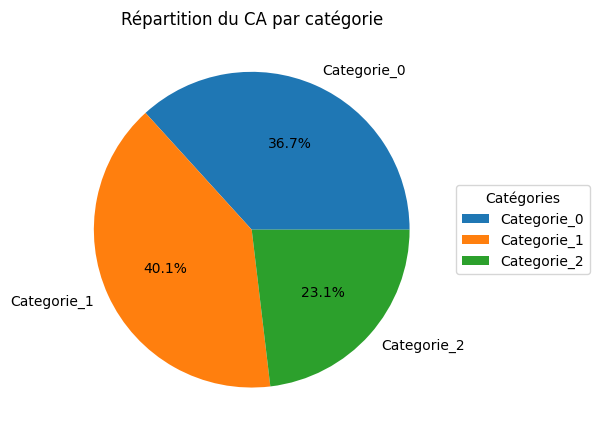

In [120]:
ca_categ = df_transactions_products_customers.groupby('categ')['CA'].sum()
# Création du graphique
ax = ca_categ.plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Répartition du CA par catégorie',
    figsize=(6, 6)
)
plt.ylabel('')  
# Ajout de la légende
plt.legend(ca_categ.index, title="Catégories", bbox_to_anchor=(1, 0.5), loc="center left")
plt.tight_layout()
plt.show()

In [121]:
# Calcul du nombre de clients uniques par mois
clients_par_mois = df_transactions_products_customers.groupby('mois')['client_id'].nunique().reset_index()
clients_par_mois.columns = ['mois', 'nb_clients']

# Conversion du format Period en string
clients_par_mois['mois'] = clients_par_mois['mois'].astype(str)

# Graphique interactif
fig = px.line(
    clients_par_mois,
    x='mois',
    y='nb_clients',
    title="Nombre de clients uniques par mois",
    markers=True,
    labels={'mois': 'Mois', 'nb_clients': 'Clients'},
    hover_data={'mois': True, 'nb_clients': True},
    color_discrete_sequence=['blue']
)

fig.update_layout(
    xaxis_title="Mois",
    yaxis_title="Nombre de clients",
    hoverlabel=dict(bgcolor="white", font_size=12),
    template="plotly_white"
)

fig.show()


In [122]:
# Comptage du nombre de transactions uniques par mois
tx_par_mois = df_transactions_products_customers.groupby('mois')['session_id'].nunique().reset_index()
tx_par_mois.columns = ['mois', 'nb_transactions']

# Conversion de 'mois' en string
tx_par_mois['mois'] = tx_par_mois['mois'].astype(str)
# Graphique interactif
fig = px.line(
    tx_par_mois,
    x='mois',
    y='nb_transactions',
    title="Nombre de transactions par mois",
    markers=True,
    labels={'mois': 'Mois', 'nb_transactions': 'Transactions'},
    hover_data={'mois': True, 'nb_transactions': True},
    color_discrete_sequence=['orange']
)
fig.update_layout(
    xaxis_title="Mois",
    yaxis_title="Nombre de transactions",
    hoverlabel=dict(bgcolor="white", font_size=12),
    template="plotly_white"
)
fig.show()

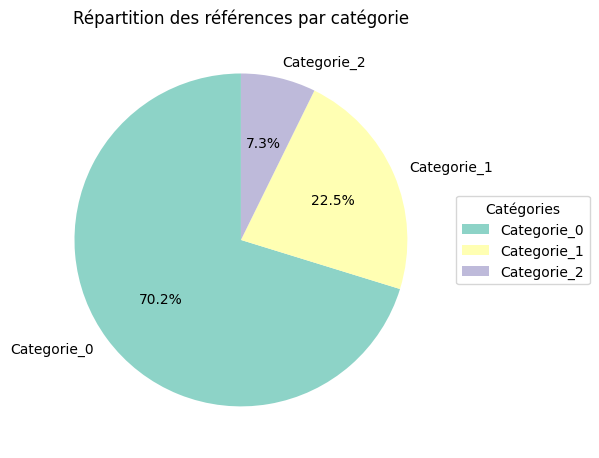

In [123]:
# Nombre de références uniques par catégorie
refs_par_categ = df_products.groupby('categ')['id_prod'].nunique()

plt.figure(figsize=(6,6))
refs_par_categ.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title("Répartition des références par catégorie")
plt.ylabel('')
plt.legend(ca_categ.index, title="Catégories", bbox_to_anchor=(1, 0.5), loc="center left")
plt.tight_layout()
plt.show()


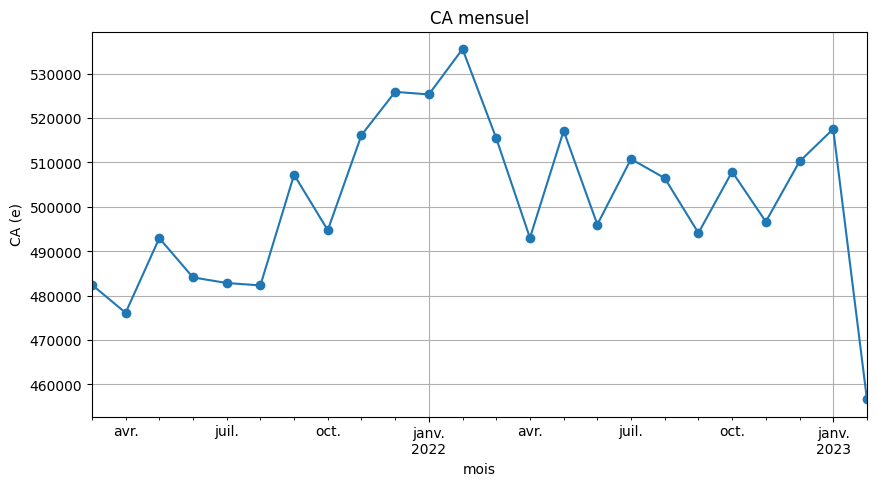

Nombre de produits vendus par catégorie (décembre) :
categ
Categorie_0    19302
Categorie_1    12259
Categorie_2      896
Name: id_prod, dtype: int64

La catégorie la plus vendue en decembre est : Categorie_0 avec 19302 produits vendus.

Chiffre d'affaires par catégorie (decembre) :
categ
Categorie_1    251026.75
Categorie_0    206036.24
Categorie_2     68854.29
Name: CA, dtype: float64


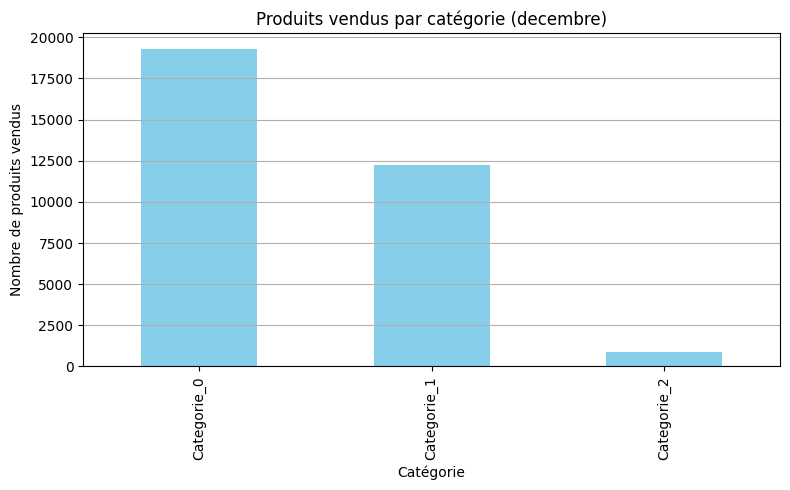

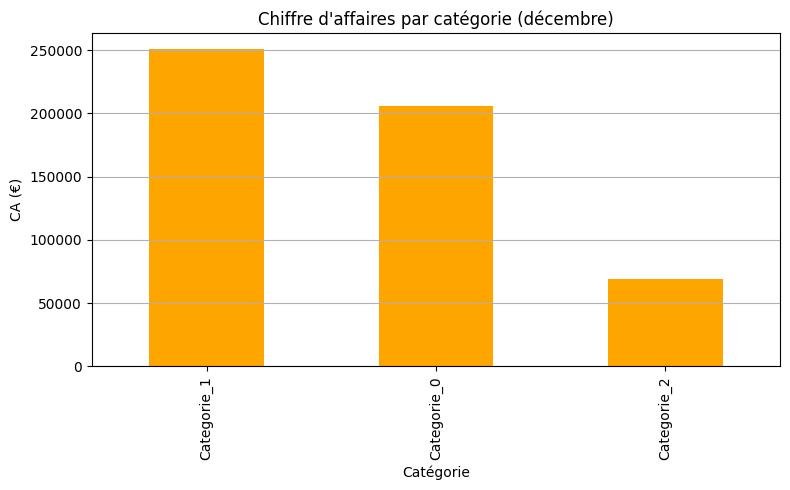

In [124]:
#CA mensuel
df_transactions_products_customers['mois'] = df_transactions_products_customers['date'].dt.to_period("M")
ca_mensuel = df_transactions_products_customers.groupby('mois')['CA'].sum()
ca_mensuel.plot(figsize=(10,5), marker='o', title="CA mensuel")
plt.ylabel("CA (e)")
plt.grid()
plt.show()
# Filtrage des données pour decembre
df_decembre = df_transactions_products_customers[df_transactions_products_customers['mois'] == '2021-12']

# Nombre de produits vendus par catégorie
categ_vendue_decembre = df_decembre.groupby('categ')['id_prod'].count().sort_values(ascending=False)

print("Nombre de produits vendus par catégorie (décembre) :")
print(categ_vendue_decembre)

# Catégorie la plus vendue (en volume)
cat_top = categ_vendue_decembre.idxmax()
nb_top = categ_vendue_decembre.max()
print(f"\nLa catégorie la plus vendue en decembre est : {cat_top} avec {nb_top} produits vendus.")

# CA par catégorie
ca_par_categ = df_decembre.groupby('categ')['CA'].sum().sort_values(ascending=False)

print("\nChiffre d'affaires par catégorie (decembre) :")
print(ca_par_categ)
# Histogramme des ventes par catégorie
categ_vendue_decembre.plot(kind='bar', color='skyblue', title='Produits vendus par catégorie (decembre)', figsize=(8,5))
plt.ylabel("Nombre de produits vendus")
plt.xlabel("Catégorie")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Création de l'histogramme
ca_par_categ.plot(kind='bar', color='orange', title='Chiffre d\'affaires par catégorie (décembre)', figsize=(8,5))
plt.ylabel("CA (€)")
plt.xlabel("Catégorie")
plt.grid(axis='y')
plt.tight_layout()
plt.show()



🔍 CATÉGORIES DISPONIBLES :
categ
Categorie_0    415459
Categorie_1    235592
Categorie_2     36483
Name: count, dtype: int64

📊 ANALYSE DE LA CATÉGORIE 2 :
Statistiques sur les prix des produits de la catégorie 2 :


count    36483.000000
mean        76.207412
std         39.749015
min         30.990000
25%         53.990000
50%         62.830000
75%         73.720000
max        300.000000
Name: price, dtype: float64


Chiffre d'affaires total pour la catégorie 2 : 2,780,275.02 €
Nombre de produits vendus dans la catégorie 2 : 36,483

📊 ANALYSE DE LA CATÉGORIE 1 :
Statistiques sur les prix des produits de la catégorie 1 :


count    235592.000000
mean         20.491600
std           7.579606
min           2.000000
25%          15.810000
50%          19.080000
75%          24.980000
max          80.990000
Name: price, dtype: float64


Chiffre d'affaires total pour la catégorie 1 : 4,827,657.11 €
Nombre de produits vendus dans la catégorie 1 : 235,592

📊 ANALYSE DE LA CATÉGORIE 0 :
Statistiques sur les prix des produits de la catégorie 0 :


count    415459.000000
mean         10.638188
std           4.933527
min           0.620000
25%           6.290000
50%           9.990000
75%          14.450000
max          40.990000
Name: price, dtype: float64


Chiffre d'affaires total pour la catégorie 0 : 4,419,730.97 €
Nombre de produits vendus dans la catégorie 0 : 415,459

🏆 TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES :
Top 10 des produits :
 1. 2_159 : 94,893.50 €
 2. 2_135 : 69,334.95 €
 3. 2_112 : 65,407.76 €
 4. 2_102 : 60,736.78 €
 5. 2_209 : 56,971.86 €
 6. 1_395 : 56,617.47 €
 7. 1_369 : 56,136.60 €
 8. 2_110 : 53,846.25 €
 9. 1_383 : 53,834.43 €
10. 1_414 : 53,522.18 €


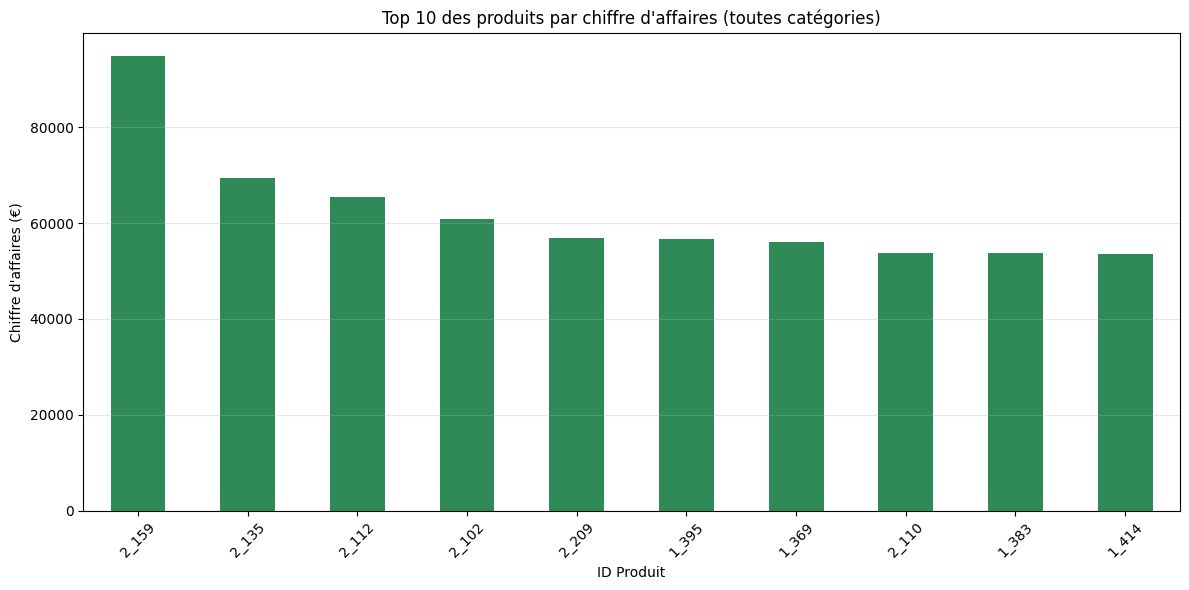


📈 CHIFFRE D'AFFAIRES PAR CATÉGORIE :


,CA_Total,Nb_Transactions,CA_Moyen
categ,,,
Categorie_0,4419730.97,415459,10.64
Categorie_1,4827657.11,235592,20.49
Categorie_2,2780275.02,36483,76.21


In [125]:
# =============================================================================
# ANALYSE PAR CATÉGORIE ET TOP 10 PRODUITS
# =============================================================================

# 1. VÉRIFICATION DES CATÉGORIES DISPONIBLES
print("🔍 CATÉGORIES DISPONIBLES :")
print(df_transactions_products_customers['categ'].value_counts().sort_index())

# 2. ANALYSE DE LA CATÉGORIE 2 
print(f"\n📊 ANALYSE DE LA CATÉGORIE 2 :")
categ_2 = df_transactions_products_customers[df_transactions_products_customers['categ'] == 'Categorie_2']

if len(categ_2) > 0:
    # Statistiques descriptives sur le prix
    print("Statistiques sur les prix des produits de la catégorie 2 :")
    display(categ_2['price'].describe())
    
    # Chiffre d'affaires total
    if 'CA' in categ_2.columns:
        ca_total = categ_2['CA'].sum()
        print(f"\nChiffre d'affaires total pour la catégorie 2 : {ca_total:,.2f} €")
    else:
        # Calculer le CA si la colonne n'existe pas
        ca_total = categ_2['price'].sum()
        print(f"\nChiffre d'affaires total pour la catégorie 2 : {ca_total:,.2f} €")
    
    # Nombre total de produits vendus
    nb_produits = categ_2.shape[0]
    print(f"Nombre de produits vendus dans la catégorie 2 : {nb_produits:,}")
else:
    print("❌ Aucun produit trouvé dans la catégorie 2")
    
# ANALYSE DE LA CATÉGORIE 1 
print(f"\n📊 ANALYSE DE LA CATÉGORIE 1 :")
categ_1 = df_transactions_products_customers[df_transactions_products_customers['categ'] == 'Categorie_1']

if len(categ_1) > 0:
    # Statistiques descriptives sur le prix
    print("Statistiques sur les prix des produits de la catégorie 1 :")
    display(categ_1['price'].describe())
    
    # Chiffre d'affaires total
    if 'CA' in categ_1.columns:
        ca_total = categ_1['CA'].sum()
        print(f"\nChiffre d'affaires total pour la catégorie 1 : {ca_total:,.2f} €")
    else:
        # Calculer le CA si la colonne n'existe pas
        ca_total = categ_1['price'].sum()
        print(f"\nChiffre d'affaires total pour la catégorie 1 : {ca_total:,.2f} €")
    
    # Nombre total de produits vendus
    nb_produits = categ_1.shape[0]
    print(f"Nombre de produits vendus dans la catégorie 1 : {nb_produits:,}")
else:
    print("❌ Aucun produit trouvé dans la catégorie 1")
    
# ANALYSE DE LA CATÉGORIE 0 
print(f"\n📊 ANALYSE DE LA CATÉGORIE 0 :")
categ_0 = df_transactions_products_customers[df_transactions_products_customers['categ'] == 'Categorie_0']

if len(categ_0) > 0:
    # Statistiques descriptives sur le prix
    print("Statistiques sur les prix des produits de la catégorie 0 :")
    display(categ_0['price'].describe())
    
    # Chiffre d'affaires total
    if 'CA' in categ_0.columns:
        ca_total = categ_0['CA'].sum()
        print(f"\nChiffre d'affaires total pour la catégorie 0 : {ca_total:,.2f} €")
    else:
        # Calculer le CA si la colonne n'existe pas
        ca_total = categ_0['price'].sum()
        print(f"\nChiffre d'affaires total pour la catégorie 0 : {ca_total:,.2f} €")
    
    # Nombre total de produits vendus
    nb_produits = categ_0.shape[0]
    print(f"Nombre de produits vendus dans la catégorie 0 : {nb_produits:,}")
else:
    print("❌ Aucun produit trouvé dans la catégorie ")
    
# ------------------------------------------------------------------------------------------------------------------

# 3. TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES (TOUTES CATÉGORIES)
print(f"\n🏆 TOP 10 PRODUITS PAR CHIFFRE D'AFFAIRES :")

# Vérifier si la colonne CA existe, sinon utiliser price
if 'CA' in df_transactions_products_customers.columns:
    ca_column = 'CA'
else:
    ca_column = 'price'
    print("⚠️ Colonne 'CA' non trouvée, utilisation de 'price'")

# Calcul du top 10
top_10_produits = df_transactions_products_customers.groupby('id_prod')[ca_column].sum().sort_values(ascending=False).head(10)

print("Top 10 des produits :")
for i, (produit, ca) in enumerate(top_10_produits.items(), 1):
    print(f"{i:2d}. {produit} : {ca:,.2f} €")

# 4. GRAPHIQUE
plt.figure(figsize=(12,6))
top_10_produits.plot(kind='bar', color='seagreen')
plt.title("Top 10 des produits par chiffre d'affaires (toutes catégories)")
plt.xlabel("ID Produit")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. ANALYSE PAR CATÉGORIE
print(f"\n📈 CHIFFRE D'AFFAIRES PAR CATÉGORIE :")
ca_par_categ = df_transactions_products_customers.groupby('categ')[ca_column].agg(['sum', 'count', 'mean']).round(2)
ca_par_categ.columns = ['CA_Total', 'Nb_Transactions', 'CA_Moyen']
display(ca_par_categ)


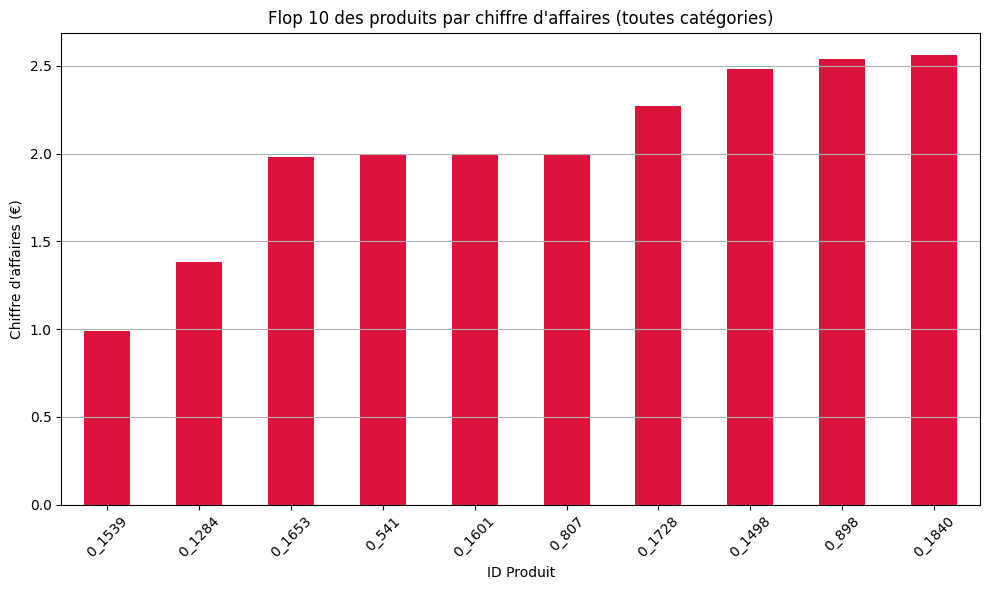

In [126]:
#flop10 produits par chiffre d'affaires
# Calcul du chiffre d'affaires total par produit (toutes catégories)
flop_10_produits = df_transactions_products_customers.groupby('id_prod')['CA'].sum().sort_values(ascending=True).head(10)

# Affichage du bar chart
plt.figure(figsize=(10,6))
flop_10_produits.plot(kind='bar', color='crimson')
plt.title("Flop 10 des produits par chiffre d'affaires (toutes catégories)")
plt.xlabel("ID Produit")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()




📈 SEGMENTATION CLIENTS BtoB vs BtoC
Seuil BtoB : 6,000€
Clients BtoB : 4
Clients BtoC : 8,596
Total clients : 8,600
Pourcentage BtoB : 0.0%
CA moyen BtoB : 221,074.02€
CA moyen BtoC : 1,296.34€


,Segment,Nombre_clients,Pourcentage,CA_moyen,CA_total,Part_CA
0,BtoC,8596,99.95,1296.34,11143367.01,92.65
1,BtoB,4,0.05,221074.02,884296.09,7.35
2,Total,8600,100.00,1398.57,12027663.10,100.00



🏆 TOP CLIENTS BtoB :
 1. c_1609 : 326,039.89€
 2. c_4958 : 290,227.03€
 3. c_6714 : 153,918.60€
 4. c_3454 : 114,110.57€


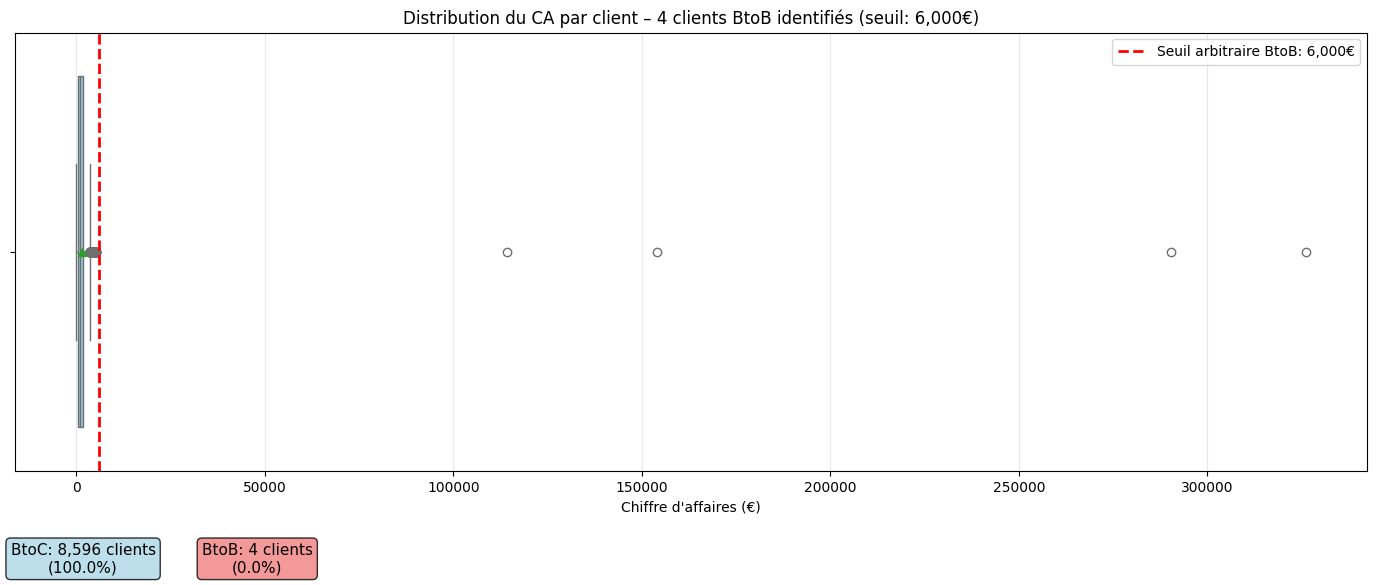

In [127]:
# =============================================================================
# SEGMENTATION CLIENTS BtoB vs BtoC - SEUIL FIXE 50K€
# =============================================================================

# CA par client
ca_clients = df_transactions_products_customers.groupby('client_id')['CA'].sum().reset_index()

# Seuil BtoB arbitraire à 6 000€
seuil_btob = 6000

# Segmentation
btob_clients = ca_clients[ca_clients['CA'] > seuil_btob]
btoc_clients = ca_clients[ca_clients['CA'] <= seuil_btob]

# 📊 STATISTIQUES
print(f"📈 SEGMENTATION CLIENTS BtoB vs BtoC")
print(f"Seuil BtoB : {seuil_btob:,}€")
print(f"="*50)
print(f"Clients BtoB : {len(btob_clients):,}")
print(f"Clients BtoC : {len(btoc_clients):,}")
print(f"Total clients : {len(ca_clients):,}")
print(f"Pourcentage BtoB : {len(btob_clients)/len(ca_clients)*100:.1f}%")
print(f"CA moyen BtoB : {btob_clients['CA'].mean():,.2f}€")
print(f"CA moyen BtoC : {btoc_clients['CA'].mean():,.2f}€")

# 📊 TABLEAU RÉCAPITULATIF
recap = pd.DataFrame({
    'Segment': ['BtoC', 'BtoB', 'Total'],
    'Nombre_clients': [len(btoc_clients), len(btob_clients), len(ca_clients)],
    'Pourcentage': [len(btoc_clients)/len(ca_clients)*100, len(btob_clients)/len(ca_clients)*100, 100],
    'CA_moyen': [btoc_clients['CA'].mean(), btob_clients['CA'].mean(), ca_clients['CA'].mean()],
    'CA_total': [btoc_clients['CA'].sum(), btob_clients['CA'].sum(), ca_clients['CA'].sum()],
    'Part_CA': [btoc_clients['CA'].sum()/ca_clients['CA'].sum()*100, 
                btob_clients['CA'].sum()/ca_clients['CA'].sum()*100, 100]
}).round(2)

display(recap)

# 🎯 TOP 10 CLIENTS BtoB
if len(btob_clients) > 0:
    print(f"\n🏆 TOP CLIENTS BtoB :")
    top_btob = btob_clients.sort_values('CA', ascending=False).head(10)
    for i, (_, row) in enumerate(top_btob.iterrows(), 1):
        print(f"{i:2d}. {row['client_id']} : {row['CA']:,.2f}€")

# 📊 GRAPHIQUE CORRIGÉ
plt.figure(figsize=(14,6))
sns.boxplot(x=ca_clients['CA'], color='skyblue', showmeans=True)
plt.axvline(seuil_btob, color='red', linestyle='--', linewidth=2,
           label=f'Seuil arbitraire BtoB: {seuil_btob:,}€')

# Annotations sur le graphique
plt.text(seuil_btob * 0.3, 0.7, 
         f'BtoC: {len(btoc_clients):,} clients\n({len(btoc_clients)/len(ca_clients)*100:.1f}%)', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
         fontsize=11, ha='center', va='center')

# Déplacer le label BtoB plus à droite
plt.text(seuil_btob * 8, 0.7,  # Augmentation de la valeur x pour le décaler à droite
         f'BtoB: {len(btob_clients):,} clients\n({len(btob_clients)/len(ca_clients)*100:.1f}%)', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8),
         fontsize=11, ha='center', va='center')


plt.title(f"Distribution du CA par client – {len(btob_clients)} clients BtoB identifiés (seuil: {seuil_btob:,}€)")
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()




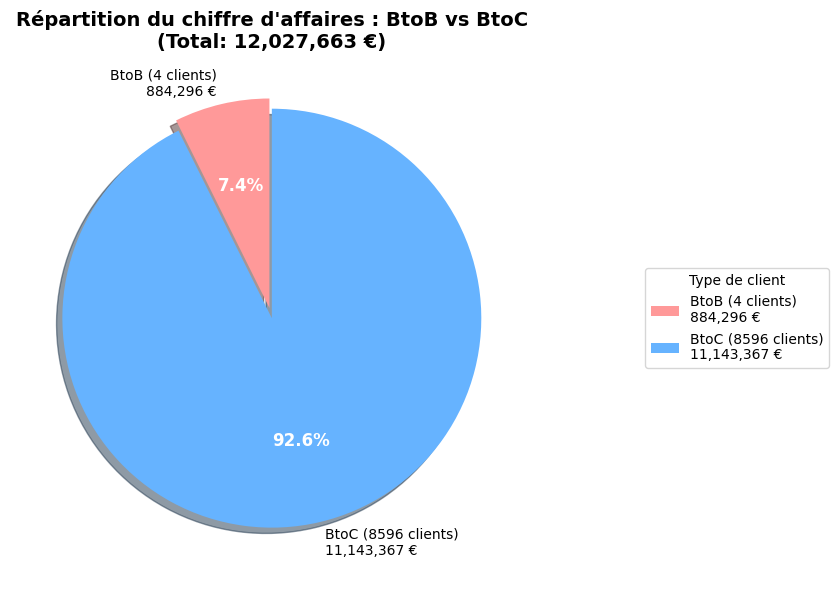

📈 ANALYSE COMPARATIVE :
CA moyen BtoB : 221,074 € par client
CA moyen BtoC : 1,296 € par client


In [128]:
# Calculs
btob_ca = btob_clients['CA'].sum()
btoc_ca = btoc_clients['CA'].sum()
total_ca = btob_ca + btoc_ca

# Labels avec plus d'infos
labels = [
    f'BtoB ({len(btob_clients)} clients)\n{btob_ca:,.0f} €',
    f'BtoC ({len(btoc_clients)} clients)\n{btoc_ca:,.0f} €'
]
sizes = [btob_ca, btoc_ca]
colors = ['#ff9999', '#66b3ff']

# Graphique
plt.figure(figsize=(10,6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,  
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0),  # Séparer légèrement la part BtoB
    shadow=True         # Ajouter une ombre
)

# Améliorer la lisibilité des pourcentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.legend(
    wedges,
    labels,
    title="Type de client",
    bbox_to_anchor=(1.2, 0.5),
    loc="center left"
)

plt.title(f"Répartition du chiffre d'affaires : BtoB vs BtoC\n(Total: {total_ca:,.0f} €)", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 📊 Statistiques complémentaires
print(f"📈 ANALYSE COMPARATIVE :")
print(f"CA moyen BtoB : {btob_ca/len(btob_clients):,.0f} € par client")
print(f"CA moyen BtoC : {btoc_ca/len(btoc_clients):,.0f} € par client")


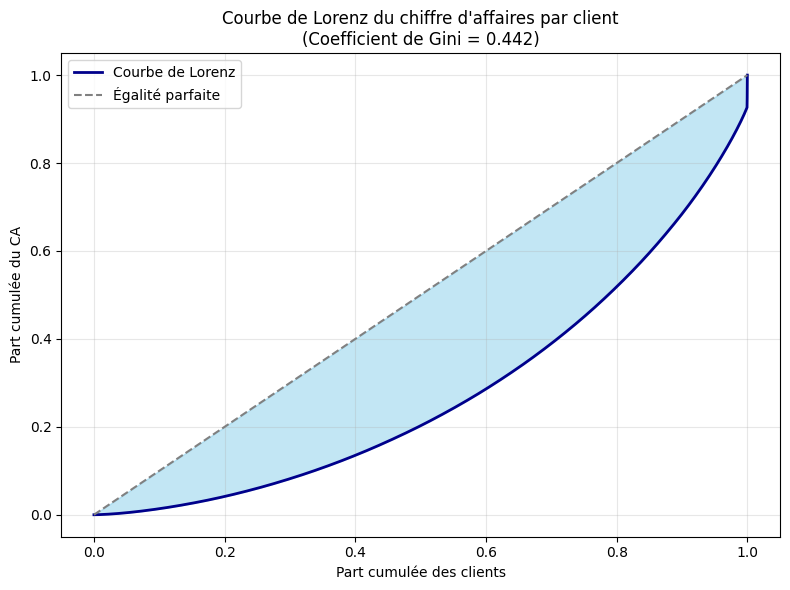

📊 Coefficient de Gini : 0.442
→ Distribution relativement équilibrée du CA


In [129]:
# =============================================================================
# COURBE DE LORENZ
# =============================================================================

# Préparer les données
sorted_ca = np.sort(ca_clients['CA'])
cum_ca = np.cumsum(sorted_ca)
lorenz = cum_ca / cum_ca[-1]  # Normalisation
lorenz = np.insert(lorenz, 0, 0)  # Ajouter 0 au début
x = np.linspace(0, 1, len(lorenz))

# Calcul du coefficient de Gini (optionnel)
gini = 1 - 2 * np.trapz(lorenz, x)

# Affichage
plt.figure(figsize=(8,6))
plt.plot(x, lorenz, label="Courbe de Lorenz", color='darkblue', linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Égalité parfaite')
plt.fill_between(x, lorenz, x, color='skyblue', alpha=0.5)
plt.title(f"Courbe de Lorenz du chiffre d'affaires par client\n(Coefficient de Gini = {gini:.3f})")
plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du CA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Coefficient de Gini : {gini:.3f}")
if gini > 0.5:
    print("→ Concentration forte du CA sur quelques clients")
else:
    print("→ Distribution relativement équilibrée du CA")


## 📈 Coefficient de Gini

Le **coefficient de Gini** est un indicateur statistique qui mesure les **inégalités de distribution** dans un ensemble de données.

### 🎯 **Principe :**
- **Valeur entre 0 et 1** (ou 0% et 100%)
- **0** = égalité parfaite (tous les clients ont le même CA)
- **1** = inégalité maximale (un seul client détient tout le CA)

### 📊 **Interprétation pour notre analyse :**
- **< 0.3** : Distribution équilibrée du CA
- **0.3 - 0.5** : Concentration modérée 
- **0.5 - 0.7** : Concentration forte
- **> 0.7** : Concentration très forte (quelques gros clients dominent)

### 🔍 **Calcul :**
Le Gini se calcule à partir de la **courbe de Lorenz** :
- Plus la courbe s'éloigne de la diagonale d'égalité, plus le Gini est élevé
- Gini = 2 × (Aire entre la diagonale et la courbe de Lorenz)

### 💼 **Utilité business :**
- **Gini élevé** → Stratégie de fidélisation des gros clients prioritaire
- **Gini faible** → Stratégie d'acquisition de masse plus pertinente


In [130]:
# Liste des clients BtoB à exclure
liste_btob = btob_clients['client_id'].tolist()

# Filtrer df_transactions_products_customers pour ne garder que les clients BtoC
df_transactions_products_customers_btoc = df_transactions_products_customers[~df_transactions_products_customers['client_id'].isin(liste_btob)].copy()
df_transactions_products_customers_btoc.to_csv('df_transactions_products_customers_btoc.csv', index=False)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Étape 4 - Corrélations demandées</h2>
</div>


chi2 : 22.6686
p-value : 0.0000
dof : 2.0000


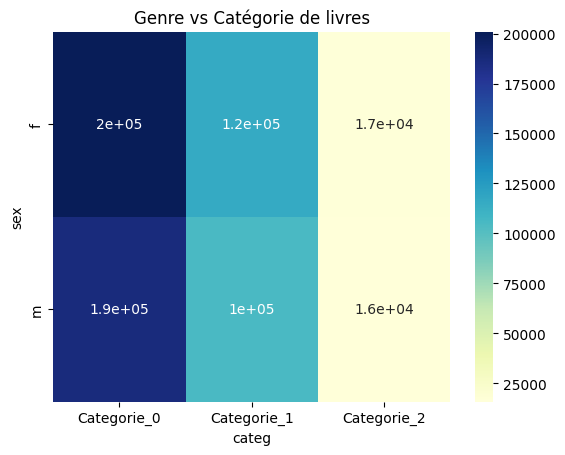

In [131]:
contingence = pd.crosstab(df_transactions_products_customers_btoc['sex'], df_transactions_products_customers_btoc['categ'])
chi2, p, dof, expected = chi2_contingency(contingence, correction = True)
print(f"chi2 : {chi2:.4f}")
print(f"p-value : {p:.4f}")
print(f"dof : {dof:.4f}")
sns.heatmap(contingence, annot=True, cmap="YlGnBu")
plt.title("Genre vs Catégorie de livres")
plt.show()


### 📈 Interprétation de la p-value

- **p-value ≈ 0** → Corrélation **statistiquement significative**
- **p < 0.05** → Résultat significatif (rejet de H0)
- **p < 0.01** → Résultat très significatif  
- **p < 0.001** → Résultat hautement significatif

### 🔍 Votre résultat :
- **Coefficient de Spearman** : mesure la force de la relation
- **p-value ≈ 0** : cette relation n'est PAS due au hasard
- **Conclusion** : Il existe bien une relation entre l'âge et le CA


Spearman coef : -0.185, p-value : 0.0000


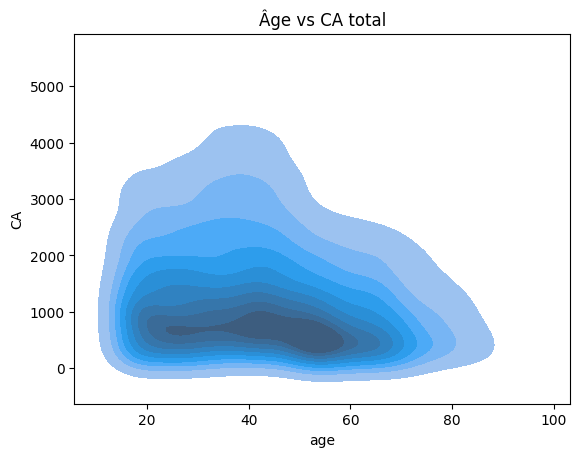

In [132]:
#Donne quantitative 
#Age
#Chiffre d'affaire
df_ca = df_transactions_products_customers_btoc.groupby('client_id').agg({'age': 'first', 'CA': 'sum'}).reset_index()
coef, p = spearmanr(df_ca['age'], df_ca['CA'])
print(f"Spearman coef : {coef:.3f}, p-value : {p:.4f}")

sns.kdeplot(data=df_ca, x='age', y='CA', fill=True)
plt.title("Âge vs CA total")
plt.show()

Spearman coef : 0.128, p-value : 0.0000


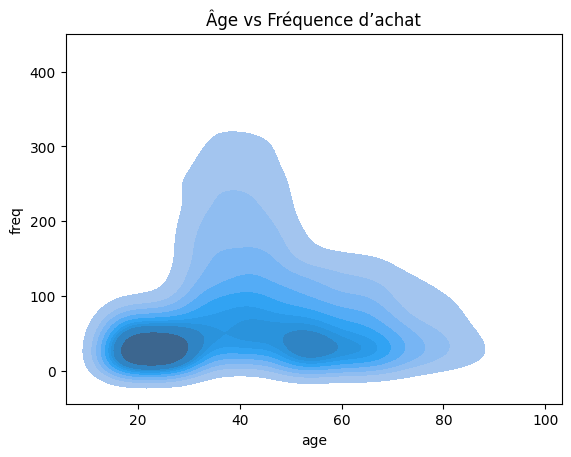

In [133]:
df_freq = df_transactions_products_customers_btoc.groupby('client_id').agg({'age': 'first', 'id_prod': 'count'}).rename(columns={'id_prod': 'freq'}).reset_index()
coef, p = spearmanr(df_freq['age'], df_freq['freq'])
print(f"Spearman coef : {coef:.3f}, p-value : {p:.4f}")

sns.kdeplot(data=df_freq, x='age', y='freq', fill=True)
plt.title("Âge vs Fréquence d’achat")
plt.show()


Spearman coef : -0.326, p-value : 0.0000


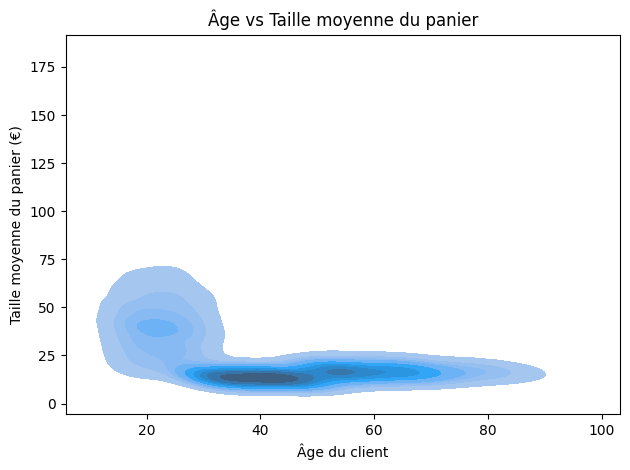

In [134]:
# Calculer CA total et fréquence d’achat par client
df_panier = df_transactions_products_customers_btoc.groupby('client_id').agg({
    'age': 'first',
    'CA': 'sum',
    'id_prod': 'count'  # nombre d’achats
}).rename(columns={'id_prod': 'freq'})

# Taille moyenne du panier = CA total / nombre d’achats
df_panier['panier_moyen'] = df_panier['CA'] / df_panier['freq']

coef, p = spearmanr(df_panier['age'], df_panier['panier_moyen'])
print(f"Spearman coef : {coef:.3f}, p-value : {p:.4f}")

sns.kdeplot(data=df_panier, x='age', y='panier_moyen', fill=True)
plt.title("Âge vs Taille moyenne du panier")
plt.xlabel("Âge du client")
plt.ylabel("Taille moyenne du panier (€)")
plt.tight_layout()
plt.show()

In [135]:
from scipy.stats import shapiro

# Test de normalité par catégorie de livres
for cat in df_transactions_products_customers_btoc['categ'].dropna().unique():
    ages = df_transactions_products_customers_btoc[df_transactions_products_customers_btoc['categ'] == cat]['age'].dropna()
    stat, p_value = shapiro(ages)
    print(f"Catégorie {cat} : p-value = {p_value:.4f}")

Catégorie Categorie_0 : p-value = 0.0000
Catégorie Categorie_1 : p-value = 0.0000
Catégorie Categorie_2 : p-value = 0.0000


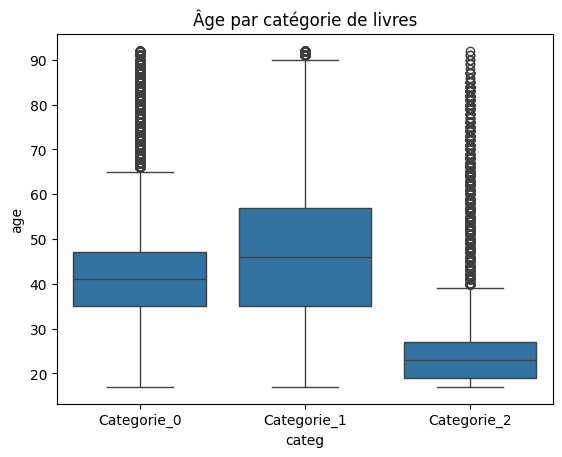

Kruskal-Wallis : stat=71359.734, p-value=0.0000


In [136]:
sns.boxplot(data=df_transactions_products_customers_btoc, x='categ', y='age')
plt.title("Âge par catégorie de livres")
plt.show()

# Test Kruskal-Wallis
groups = [g['age'].dropna() for _, g in df_transactions_products_customers_btoc.groupby('categ')]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis : stat={stat:.3f}, p-value={p:.4f}")

## 🧪 Test de Kruskal-Wallis

### 🎯 **Principe :**
Le test de **Kruskal-Wallis** est un test statistique non-paramétrique qui compare les **médianes** de plusieurs groupes indépendants.

### 📋 **Utilisation :**
- **Alternative non-paramétrique** à l'ANOVA
- Compare 3 groupes ou plus (ex: catégories de produits, tranches d'âge...)
- Ne nécessite pas de distribution normale des données
- Teste si au moins un groupe diffère significativement des autres

### 🔍 **Hypothèses :**
- **H0** : Toutes les médianes sont égales (pas de différence entre groupes)
- **H1** : Au moins une médiane diffère des autres

### 📊 **Interprétation des résultats :**


### 🧪 Kruskal-Wallis
Test qui compare les médianes de plusieurs groupes :
- **p ≈ 0** = Différences **hautement significatives** entre groupes
- **Conclusion** : Les groupes ont des comportements distincts


## Justification du choix Kruskal-Wallis vs ANOVA

### Pourquoi Kruskal-Wallis ?
- **Données non-normales** : Test de Shapiro montre p < 0.05 pour plusieurs catégories
- **Robustesse** : Moins sensible aux outliers que l'ANOVA
- **Même objectif** : Compare les distributions de plusieurs groupes indépendants
- **Plus approprié** pour des données de vente (souvent asymétriques)

### Validation :
Le test de normalité par catégorie confirme que les conditions de l'ANOVA ne sont pas respectées, justifiant l'usage de Kruskal-Wallis.
